In [6]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
from glob import glob
from sklearn.model_selection import train_test_split

In [7]:

def get_transform(image_size=256):
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)), #interpolation: BILINEAR
        transforms.ToTensor() #returns a tensor like [channel, H, W] with values [0.,1.]
        ])

    return transform

class MayoDataset(Dataset):

    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        image = Image.open(img_path).convert("L")

        if self.transform:
            image = self.transform(image)

        return image
    

DATASET_PATH = "../data/raw"

all_images = glob(
    os.path.join(DATASET_PATH, "**", "*.png"),
    recursive=True
)

print("Found images:", len(all_images))

train_images, temp_images = train_test_split(
    all_images,
    test_size=0.3,
    random_state=42
)

val_images, test_images = train_test_split(
    temp_images,
    test_size=0.5,
    random_state=42
)

transform = get_transform()

train_dataset = MayoDataset(train_images, transform)
val_dataset = MayoDataset(val_images, transform)
test_dataset = MayoDataset(test_images, transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Found images: 3633
Train: 2543
Validation: 545
Test: 545


=== DATASET SPLIT ===
Totale immagini:  3633
Train:            2543 (70.0%)
Validation:       545 (15.0%)
Test:             545 (15.0%)

=== TYPE & SHAPE CHECK ===
Tipo:             <class 'torch.Tensor'>
Shape:            torch.Size([1, 256, 256])
Dtype:            torch.float32
Min value:        0.0000
Max value:        0.9020
Valori in [0,1]:  True

=== BATCH CHECK ===
Tipo batch:       <class 'torch.Tensor'>
Shape batch:      torch.Size([8, 1, 256, 256])
Dtype batch:      torch.float32

=== DIMENSIONI ORIGINALI (prime 5 immagini) ===
  300.png                                  → 512x512 px
  13.png                                   → 512x512 px
  317.png                                  → 512x512 px
  132.png                                  → 512x512 px
  311.png                                  → 512x512 px


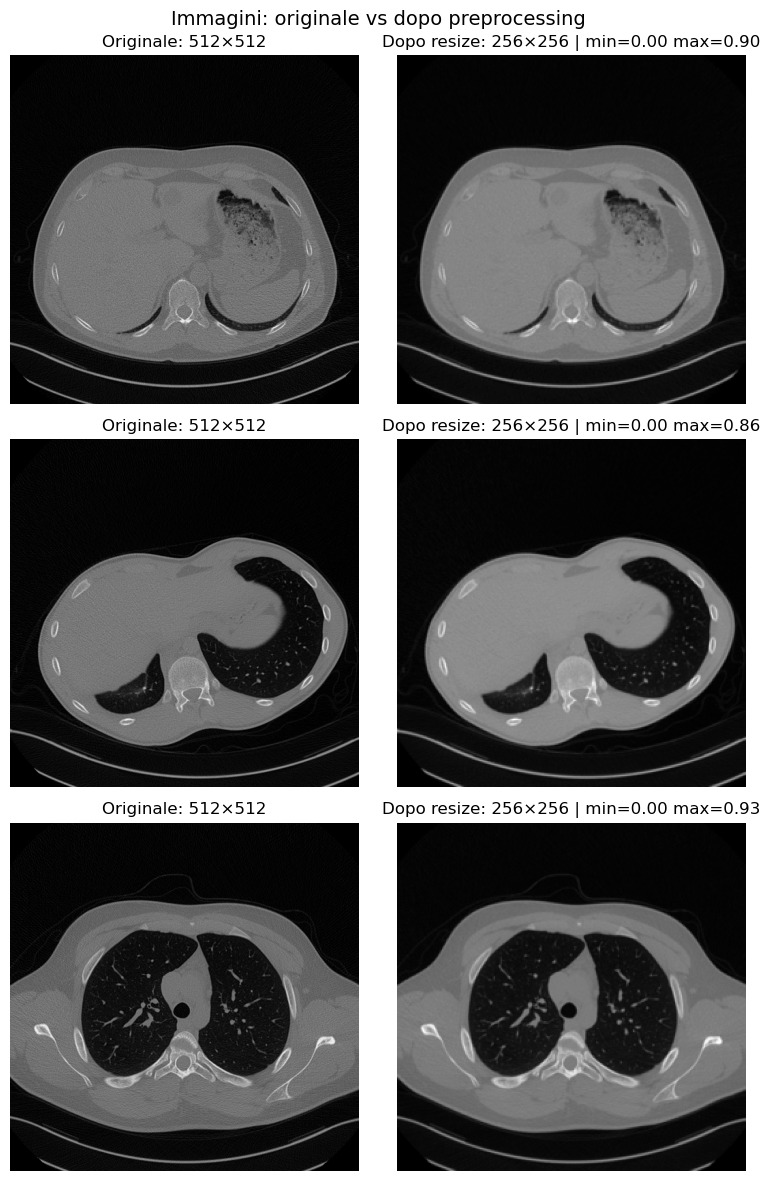


=== ISTOGRAMMA VALORI PIXEL ===


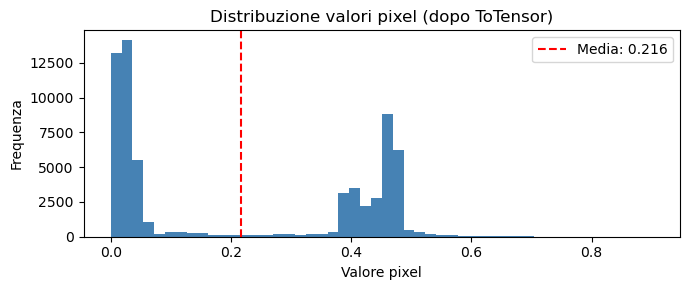

Shape sinogramma:  (256, 45)
Min:               1.7899
Max:               104.2735
Media:             54.3938
Std:               31.7131


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# CHECK 1: Quante immagini hai trovato e come sono distribuite
# ============================================================
print("=== DATASET SPLIT ===")
print(f"Totale immagini:  {len(all_images)}")
print(f"Train:            {len(train_images)} ({len(train_images)/len(all_images)*100:.1f}%)")
print(f"Validation:       {len(val_images)} ({len(val_images)/len(all_images)*100:.1f}%)")
print(f"Test:             {len(test_images)} ({len(test_images)/len(all_images)*100:.1f}%)")

# ============================================================
# CHECK 2: Controlla i tipi e le shape dei tensori
# ============================================================
print("\n=== TYPE & SHAPE CHECK ===")
sample_tensor = train_dataset[0]
print(f"Tipo:             {type(sample_tensor)}")
print(f"Shape:            {sample_tensor.shape}")          # atteso: [1, 256, 256]
print(f"Dtype:            {sample_tensor.dtype}")          # atteso: torch.float32
print(f"Min value:        {sample_tensor.min():.4f}")      # atteso: >= 0.0
print(f"Max value:        {sample_tensor.max():.4f}")      # atteso: <= 1.0
print(f"Valori in [0,1]:  {(sample_tensor >= 0).all() and (sample_tensor <= 1).all()}")

# ============================================================
# CHECK 3: Controlla un batch del DataLoader
# ============================================================
print("\n=== BATCH CHECK ===")
batch = next(iter(train_loader))
print(f"Tipo batch:       {type(batch)}")
print(f"Shape batch:      {batch.shape}")    # atteso: [8, 1, 256, 256]
print(f"Dtype batch:      {batch.dtype}")

# ============================================================
# CHECK 4: Controlla le dimensioni ORIGINALI prima del resize
#           (per capire quanto stiamo ridimensionando)
# ============================================================
print("\n=== DIMENSIONI ORIGINALI (prime 5 immagini) ===")
for path in all_images[:5]:
    img = Image.open(path).convert("L")
    print(f"  {os.path.basename(path):40s} → {img.size[0]}x{img.size[1]} px")

# ============================================================
# CHECK 5: Visualizza prima e dopo il resize
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(8, 12))
fig.suptitle("Immagini: originale vs dopo preprocessing", fontsize=14)

for i in range(3):
    path = train_images[i]
    
    # Originale (grayscale, senza transform)
    img_orig = Image.open(path).convert("L")
    axes[i, 0].imshow(img_orig, cmap="gray")
    axes[i, 0].set_title(f"Originale: {img_orig.size[0]}×{img_orig.size[1]}")
    axes[i, 0].axis("off")
    
    # Dopo transform (tensor → numpy per visualizzare)
    img_transformed = train_dataset[i]
    axes[i, 1].imshow(img_transformed.squeeze().numpy(), cmap="gray")
    axes[i, 1].set_title(f"Dopo resize: 256×256 | min={img_transformed.min():.2f} max={img_transformed.max():.2f}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# CHECK 6: Istogramma dei valori dei pixel (verifica normalizzazione)
# ============================================================
print("\n=== ISTOGRAMMA VALORI PIXEL ===")
sample_values = train_dataset[0].numpy().flatten()

plt.figure(figsize=(7, 3))
plt.hist(sample_values, bins=50, color="steelblue", edgecolor="none")
plt.title("Distribuzione valori pixel (dopo ToTensor)")
plt.xlabel("Valore pixel")
plt.ylabel("Frequenza")
plt.axvline(sample_values.mean(), color="red", linestyle="--", label=f"Media: {sample_values.mean():.3f}")
plt.legend()
plt.tight_layout()
plt.show()


[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 118. 119. 120. 121. 122. 123. 124. 125.
 126. 127. 128. 129. 130. 131. 132. 133. 134. 135. 136. 137. 138. 139.
 140. 141. 142. 143. 144. 145. 146. 147. 148. 149. 150. 151. 152. 153.
 154. 155. 156. 157. 158. 159. 160. 161. 162. 163. 164. 165. 166. 167.
 168. 169. 170. 171. 172. 173. 174. 175. 176. 177. 178. 179.]


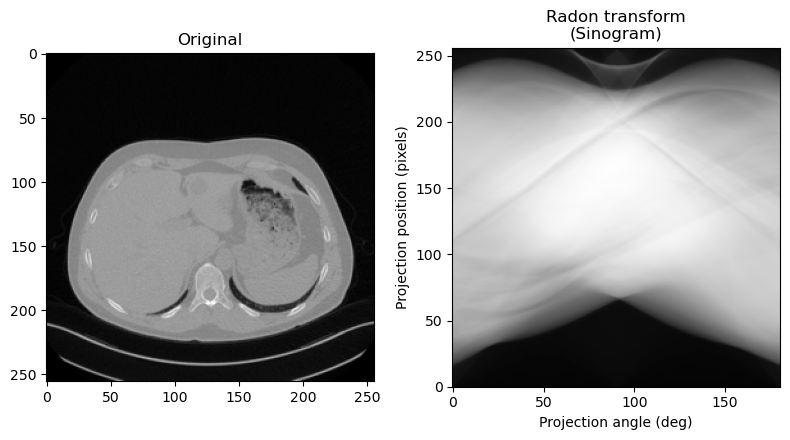

[  0.   2.   4.   6.   8.  10.  12.  14.  16.  18.  20.  22.  24.  26.
  28.  30.  32.  34.  36.  38.  40.  42.  44.  46.  48.  50.  52.  54.
  56.  58.  60.  62.  64.  66.  68.  70.  72.  74.  76.  78.  80.  82.
  84.  86.  88.  90.  92.  94.  96.  98. 100. 102. 104. 106. 108. 110.
 112. 114. 116. 118. 120. 122. 124. 126. 128. 130. 132. 134. 136. 138.
 140. 142. 144. 146. 148. 150. 152. 154. 156. 158. 160. 162. 164. 166.
 168. 170. 172. 174. 176. 178.]


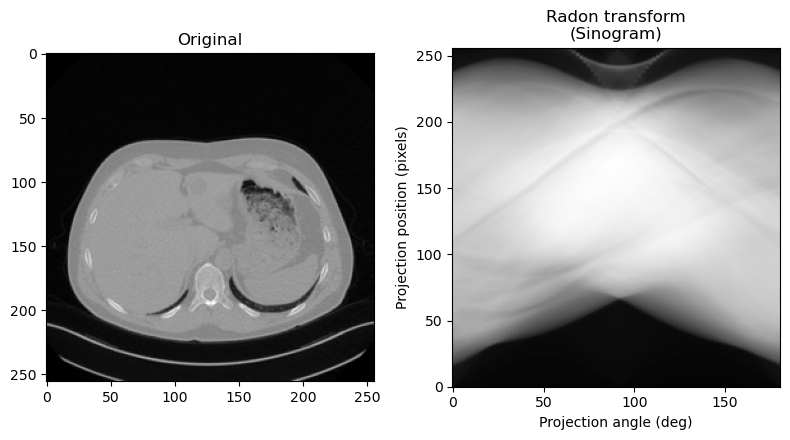

[  0.   3.   6.   9.  12.  15.  18.  21.  24.  27.  30.  33.  36.  39.
  42.  45.  48.  51.  54.  57.  60.  63.  66.  69.  72.  75.  78.  81.
  84.  87.  90.  93.  96.  99. 102. 105. 108. 111. 114. 117. 120. 123.
 126. 129. 132. 135. 138. 141. 144. 147. 150. 153. 156. 159. 162. 165.
 168. 171. 174. 177.]


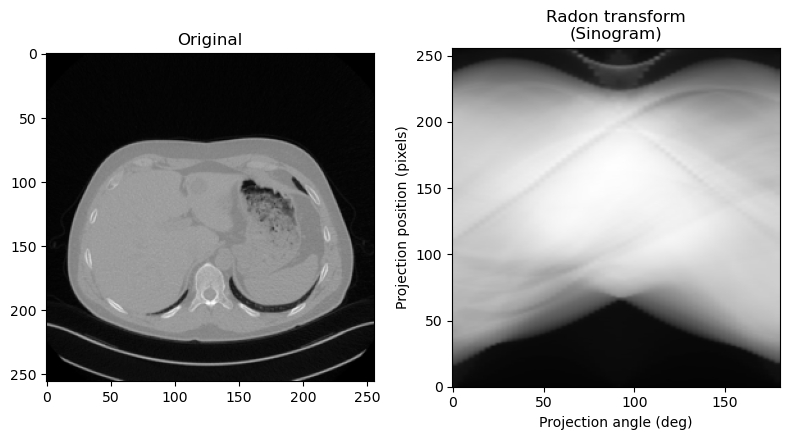

[  0.   4.   8.  12.  16.  20.  24.  28.  32.  36.  40.  44.  48.  52.
  56.  60.  64.  68.  72.  76.  80.  84.  88.  92.  96. 100. 104. 108.
 112. 116. 120. 124. 128. 132. 136. 140. 144. 148. 152. 156. 160. 164.
 168. 172. 176.]


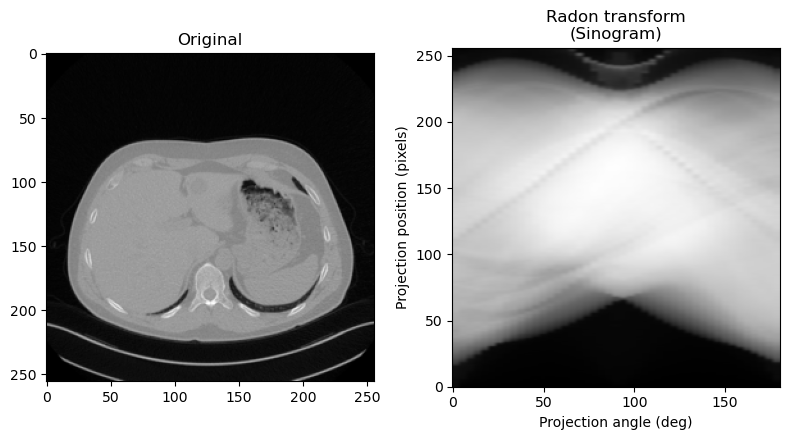

Shape sinogramma:  (256, 45)
Min:               1.7899
Max:               104.2735
Media:             54.3938
Std:               31.7131


In [ ]:
from skimage.transform import radon
ANGLE_CONFIGS = [180, 90, 60, 45]
for i in ANGLE_CONFIGS:     
    n_angles = i 
    angles = np.linspace(0, 180, n_angles, endpoint=False)
    print(angles)
    sinogram = radon(train_dataset[0].squeeze(), theta=angles)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4.5))

    ax1.set_title("Original")
    ax1.imshow(train_dataset[0].squeeze(), cmap=plt.cm.Greys_r)

    dx, dy = 0.5 * 180.0 / max(train_dataset[0].squeeze().shape), 0.5 / sinogram.shape[0]
    ax2.set_title("Radon transform\n(Sinogram)")
    ax2.set_xlabel("Projection angle (deg)")
    ax2.set_ylabel("Projection position (pixels)")
    ax2.imshow(
        sinogram,
        cmap=plt.cm.Greys_r,
        extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
        aspect='auto',
    )

    fig.tight_layout()
    plt.show()

img_2d = train_dataset[0].squeeze().numpy()
sinogram = radon(img_2d, theta=angles)

print(f"Shape sinogramma:  {sinogram.shape}")       # [256, n_angles]
print(f"Min:               {sinogram.min():.4f}")
print(f"Max:               {sinogram.max():.4f}")
print(f"Media:             {sinogram.mean():.4f}")
print(f"Std:               {sinogram.std():.4f}")